Core Multi-Agent System

In [123]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun, ArxivQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

In [124]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [125]:
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

In [126]:
## Define the state
class AgentState(MessagesState):
    next_agent:str #which agent should go next 

In [127]:
# Create simple tools 

# Initialize the tools
arxiv_tool = ArxivAPIWrapper()
wiki_tool = WikipediaAPIWrapper()
ddg_tool = DuckDuckGoSearchRun()

@tool
def search_arxiv(query: str) -> str:
    """Search Arxiv for academic papers related to the query."""
    results = arxiv_tool.run(query, max_results=3)
    return str(results)

@tool
def search_wikipedia(query: str) -> str:
    """Search Wikipedia for information about the query."""
    results = wiki_tool.run(query)
    return str(results)

@tool
def search_duckduckgo(query: str) -> str:
    """Search the web using DuckDuckGo for general information."""
    results = ddg_tool.run(query, max_results=3)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    # Simple summary generation
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary


In [128]:
from langchain.chat_models import init_chat_model

llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000002D10322DFD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002D103220DD0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [129]:
# Define agent functions

def research_agent(state: AgentState):
    """Research agent that gathers information"""
    
    messages = state["messages"]
    
    system_msg = SystemMessage(
        content=(
            "You are a research assistant. Use the search tools "
            "(search_arxiv, search_wikipedia, search_duckduckgo) to find information about the user's request."
        )
    )
    
    research_llm = llm.bind_tools([search_arxiv, search_wikipedia, search_duckduckgo])
    response = research_llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "analysis_agent"
    }

In [130]:
def analysis_agent(state: AgentState):
    """Analysis agent that extracts insights from gathered data"""
    
    messages = state["messages"]
    
    system_msg = SystemMessage(
        content=(
            "You are an analysis assistant. Review the gathered information and extract key insights or important points."
        )
    )
    
    analysis_llm = llm.bind_tools([write_summary])
    response = analysis_llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "summary_agent"
    }

In [131]:
def summary_agent(state: AgentState):
    """Summary agent that creates a final summary"""
    
    messages = state["messages"]
    
    system_msg = SystemMessage(
        content="You are a technical writer. Create a clear and concise summary of the findings."
    )
    
    summary_llm = llm.bind_tools([write_summary])
    response = summary_llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

In [132]:
# Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    
    messages = state["messages"]
    last_message = messages[-1]
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_node = ToolNode([search_arxiv, search_wikipedia, search_duckduckgo, write_summary])
        response = tool_node.invoke(state)
        return response
    
    return state

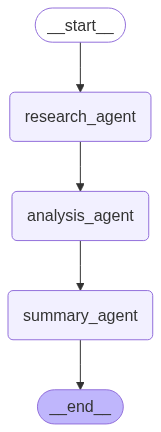

In [133]:
# Build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("research_agent", research_agent)
workflow.add_node("analysis_agent", analysis_agent)
workflow.add_node("summary_agent", summary_agent)

# Define flow
workflow.set_entry_point("research_agent")
workflow.add_edge("research_agent", "analysis_agent")
workflow.add_edge("analysis_agent", "summary_agent")
workflow.add_edge("summary_agent", END)

# Compile the workflow
final_workflow = workflow.compile()

final_workflow


In [134]:
# Run the research agent (produces tool_call)
state = research_agent({
    "messages": [HumanMessage(content="Explore the benefits and challenges of using agentic AI in enterprise decision-making")]
})
# Execute any pending tool calls (actually runs write_summary)
state = execute_tools(state)
# Pass the updated state to analysis agent
state = analysis_agent(state)
# Execute any tool calls from analysis agent (if any)
state = execute_tools(state)
# Pass the updated state to summary agent
state = summary_agent(state)
# Execute summary_agent's tool calls (if any)
state = execute_tools(state)
# Print final output
for msg in state.get("messages", []):
    print(msg.content)


c:\Users\Jesut\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


Summary of findings:

Agentic AI is a class of artificial intelligence that focuses on autonomous systems that can make decisions and perform tasks without human intervention. The independent systems automatically respond to conditions, to produce process results. This type of AI has the potential to transform various industries and aspects of our lives, but it also raises concerns about accountability and control....
Summary of findings:

Manus (meaning hands in Latin) is an autonomous artificial intelligence agent developed by the same startup that created Monica, headquartered in Singapore. The agent is designed to independently carry out complex real-world tasks without direct or continuous human guidance. Manus is a significant step forward in the development of autonomous AI agents, but its capabilities and limitations need to be carefully evaluated....
Summary of findings:

Automated decision-making (ADM) is the use of data, machines and algorithms to make decisions in a range o

Supervisor-Driven Agent System

In [135]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

In [136]:
# ===================================
# State Definition
# ===================================

from langgraph.graph import MessagesState
from typing import List

class SupervisorState(MessagesState):
    """State for the Planner → Researcher → Interpreter → Illustrator workflow"""

    next_agent: str = ""                # Which agent should run next
    mission_plan: str = ""              # Output from Planner: task breakdown/subtasks
    research_data: str = ""             # Collected information from Researcher
    interpreted_insights: str = ""      # Insights derived by Interpreter
    illustrations: str = ""             # Visuals, charts, or structured summaries from Illustrator
    task_complete: bool = False         # Flag to mark workflow completion
    assignment: str = ""                # Original user request
    history_log: List[str] = []         # Optional: track key steps and outputs


In [137]:
# ===================================
# Supervisor with Groq LLM
# ===================================
from langchain_core.prompts import ChatPromptTemplate

def create_supervisor_chain():
    """Creates the supervisor decision chain for the 4-agent workflow"""

    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:

1. Planner      - Breaks down the user task into sub-tasks
2. Researcher   - Gathers information and data
3. Interpreter  - Analyzes data and derives insights
4. Illustrator  - Creates visuals and structured summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has mission plan: {has_plan}
- Has research data: {has_research}
- Has interpreted insights: {has_insights}
- Has illustrations/summary: {has_illustrations}

Respond with ONLY the agent name (planner/researcher/interpreter/illustrator) or 'DONE'.
"""),
        ("human", "{assignment}")
    ])

    return supervisor_prompt | llm


In [138]:
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM for 4-agent workflow"""

    messages = state.get("messages", [])
    task = messages[-1].content if messages else "No task"

    # Check what's been completed
    has_plan = bool(state.get("mission_plan", ""))
    has_research = bool(state.get("research_data", ""))
    has_insights = bool(state.get("interpreted_insights", ""))
    has_illustrations = bool(state.get("illustrations", ""))

    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "assignment": task,
        "has_plan": has_plan,
        "has_research": has_research,
        "has_insights": has_insights,
        "has_illustrations": has_illustrations
    })

    # Parse decision
    decision_text = decision.content.strip().lower()
    print(f"Supervisor Decision: {decision_text}")

    # Determine next agent
    if "done" in decision_text or has_illustrations:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif "planner" in decision_text or not has_plan:
        next_agent = "planner"
        supervisor_msg = "📋 Supervisor: Let's create a plan. Assigning to Planner..."
    elif "researcher" in decision_text or (has_plan and not has_research):
        next_agent = "researcher"
        supervisor_msg = "📋 Supervisor: Plan ready. Time for research. Assigning to Researcher..."
    elif "interpreter" in decision_text or (has_research and not has_insights):
        next_agent = "interpreter"
        supervisor_msg = "📋 Supervisor: Research done. Extracting insights. Assigning to Interpreter..."
    elif "illustrator" in decision_text or (has_insights and not has_illustrations):
        next_agent = "illustrator"
        supervisor_msg = "📋 Supervisor: Insights ready. Creating visuals/summary. Assigning to Illustrator..."
    else:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: Task seems complete."

    # Preserve all previous state fields!
    new_state = dict(state)
    new_state.update({
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    })
    return new_state





In [139]:
# ===================================
# Agent 1: Planner (using Groq)
# ===================================

def planner_agent(state: SupervisorState) -> Dict:
    """Planner breaks down the task into subtasks"""

    task = state.get("assignment", "New Task")
    
    plan_prompt = f"""You are a planner. Break the following task into a clear step-by-step plan:
Task: {task}
Provide numbered steps and make it actionable for the next agents."""

    plan_response = llm.invoke([HumanMessage(content=plan_prompt)])
    mission_plan = plan_response.content

    agent_message = f"🗂️ Planner: I've created the mission plan for '{task}'.\n\nPlan:\n{mission_plan[:500]}..."
    
    new_state = dict(state)
    new_state.update({
    "messages": [AIMessage(content=agent_message)],
    "mission_plan": mission_plan,
    "next_agent": "supervisor",
    "history_log": state.get("history_log", []) + [agent_message],
})
    return new_state


In [140]:
# ===================================
# Agent 2: Researcher (using Groq)
# ===================================

def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher gathers information based on the plan"""

    task = state.get("assignment", "research topic")
    
    research_prompt = f"""As a research specialist, gather comprehensive information about: {task}
Include key facts, trends, statistics, and notable examples.
Use concise and accurate language."""

    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content

    agent_message = f"🔍 Researcher: I've completed research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."

    new_state = dict(state)
    new_state.update({
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor",
        
        "history_log": state.get("history_log", []) + [agent_message]
    })

    return new_state

In [141]:
# ===================================
# Agent 3: Interpreter (using Groq)
# ===================================

def interpreter_agent(state: SupervisorState) -> Dict:
    research_data = state.get("research_data", "")
    interpret_prompt = f"Analyze and extract insights from:\n{research_data}"
    interpret_response = llm.invoke([HumanMessage(content=interpret_prompt)])
    interpreted_insights = interpret_response.content

    agent_message = f"🧠 Interpreter: Extracted insights.\n{interpreted_insights[:500]}..."
    new_state = dict(state)
    new_state.update({
        "messages": [AIMessage(content=agent_message)],
        "interpreted_insights": interpreted_insights,
        "next_agent": "supervisor",
        "history_log": state.get("history_log", []) + [agent_message],
    })
    return new_state

In [142]:
# ===================================
# Agent 4: Illustrator (using Groq)
# ===================================

def illustrator_agent(state: SupervisorState) -> Dict:
    """Illustrator creates visuals and structured summary"""

    insights = state.get("interpreted_insights", "")

    illustrate_prompt = f"""You are an illustrator. Using the insights below, create a structured summary and suggest visuals or charts for key points:
{insights}
Format clearly for presentation."""

    illustrate_response = llm.invoke([HumanMessage(content=illustrate_prompt)])
    illustrations = illustrate_response.content

    agent_message = f"🎨 Illustrator: Structured summary and suggested visuals ready.\n\n{illustrations[:500]}..."

    # Determine if workflow is complete
    task_complete = all([
        state.get("mission_plan"),
        state.get("research_data"),
        state.get("interpreted_insights"),
        illustrations
    ])

    next_agent = "end" if task_complete else "supervisor"

    new_state = dict(state)
    new_state.update({
        "messages": [AIMessage(content=agent_message)],
        "illustrations": illustrations,
        "next_agent": next_agent,
        "task_complete": task_complete,
        "history_log": state.get("history_log", []) + [agent_message]
    })

    return new_state

In [143]:
# ===================================
# Router Function
# ===================================

from typing import Literal

def router(state: SupervisorState) -> Literal[
    "supervisor", "planner", "researcher", "interpreter", "illustrator", "__end__"
]:
    """Routes to the next agent based on the SupervisorState"""

    next_agent = state.get("next_agent", "supervisor")

    # End condition
    if next_agent == "end" or state.get("task_complete", False):
        return END

    # Valid next agents in the 4-agent workflow
    if next_agent in ["supervisor", "planner", "researcher", "interpreter", "illustrator"]:
        return next_agent

    # Default fallback
    return "supervisor"


In [144]:
# ===================================
# Create 4-Agent Workflow
# ===================================

# Initialize workflow with SupervisorState
workflow = StateGraph(SupervisorState)

# Add nodes for all agents
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("planner", planner_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("interpreter", interpreter_agent)   # or 'synthesizer' if renamed
workflow.add_node("illustrator", illustrator_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing using updated router
for node in ["supervisor", "planner", "researcher", "interpreter", "illustrator"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "planner": "planner",
            "researcher": "researcher",
            "interpreter": "interpreter",
            "illustrator": "illustrator",
            "__end__": "__end__"
        }
    )

# Compile the workflow
graph = workflow.compile()


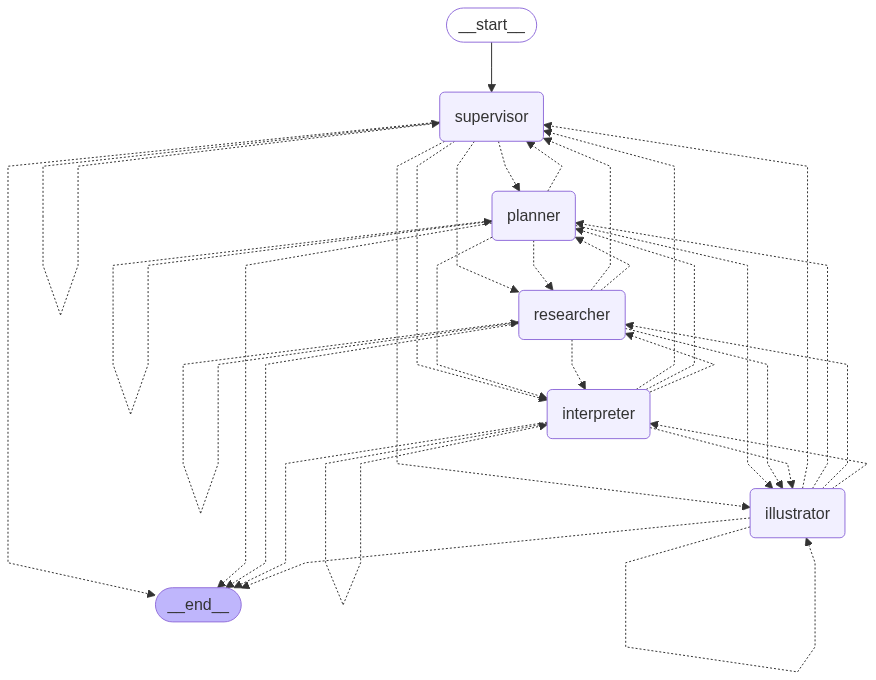

In [145]:
graph

In [146]:
response = graph.invoke({
    "messages": [HumanMessage(content="How can autonomous AI improve decision-making in supply chain management?")],
    "assignment": "How can autonomous AI improve decision-making in supply chain management?",
    "task_complete": False,
    "history_log": []
})

Supervisor Decision: planner
Supervisor Decision: researcher
Supervisor Decision: interpreter
Supervisor Decision: illustrator


In [148]:
print(response.get("illustrations", ""))

**Structured Summary and Visuals**

I. **Autonomous AI Revolutionizes Supply Chain Management**

* **Key Benefits:**
	+ Data analysis and visualization
	+ Predictive analytics
	+ Route optimization
	+ Inventory management
	+ Automated decision-making
* **Illustration:** A flowchart showing the different stages of autonomous AI adoption in supply chain management, with arrows indicating the benefits and efficiency gains.

II. **Trends in Supply Chain AI Adoption**

* **Increased Adoption:** 72% of companies plan to invest in AI and analytics in the next three years
* **Cloud-based Solutions:** Scalable and secure infrastructure for supply chain analytics
* **Integration with IoT Devices:** Real-time data collection and analysis
* **Collaborative Robots:** Improved efficiency and reduced labor costs
* **Visuals:**
	+ A bar chart showing the growth in supply chain AI adoption over the years
	+ A diagram illustrating the integration of cloud-based solutions and IoT devices in supply chain 